In [1]:
import numpy as np
import mne
import os
import pywt
import scipy.io as sio
from scipy import signal
from scipy.signal import hilbert
from matplotlib.ticker import ScalarFormatter
from statsmodels.tsa.stattools import acf
from scipy.ndimage import gaussian_filter1d


from NeuralFieldManifold.models import AR, TAR
from NeuralFieldManifold.embedders import embed
from NeuralFieldManifold.pub_utils import *

# capture future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

set_pub_style()

import numpy as np
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import plotly.graph_objects as go
from NeuralFieldManifold.fits.two_torus import two_torus_fit, plot_two_torus_fit

/home/potato/miniconda3/envs/manifold/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
xs, time, Fs = np.load("data/monkey_15_min.npz").values()
xs_rescaled = (xs - np.min(xs)) / (np.max(xs) - np.min(xs)) * 2 - 1

In [3]:
def sweep_fits(windows, lam=0.1, n_jobs=-1):
    fits = Parallel(n_jobs=n_jobs)(
        delayed(two_torus_fit)(w['points'], lam=lam)
        for w in windows
    )
    return [{**w, **f} for w, f in zip(windows, fits)]

def make_windows(xs, Fs, embedding_dim, tau, starts_sec, window_sec=2):
    window_samples = int(window_sec * Fs)
    windows = []
    for t in starts_sec:
        start = int(t * Fs)
        segment = xs[start:start + window_samples]
        pts = np.asarray(embed(segment, embedding_dim, tau))
        windows.append({
            'points': pts,
            'start_sec': t,
            'end_sec': t + window_sec,
        })
    return windows

In [4]:
def generate_bad_ar_data(n_samples=600, ar_order=2, seed=None):
    """AR process with only real poles (no oscillatory modes), driven by white noise."""
    rng = np.random.default_rng(seed)

    if ar_order == 2:
        # two real stable poles — no oscillation
        p1, p2 = 0.6, -0.4
        a1 = p1 + p2        # 0.2
        a2 = -(p1 * p2)     # 0.24
        coeffs = np.array([a1, a2])
    elif ar_order == 4:
        # four real stable poles — no oscillation
        poles = np.array([0.55, -0.45, 0.35, -0.25])
        poly = np.polynomial.polynomial.polyfromroots(poles)
        # polyfromroots gives [c0, c1, ..., cn] for c0 + c1*z + ...
        # AR coeffs are -poly[:-1][::-1] / poly[-1] but poly[-1]=1 for monic
        # Actually for z^4 - a1*z^3 - ... = (z-p1)(z-p2)(z-p3)(z-p4)
        # easier: use np.poly which gives [1, -a1, -a2, ...] descending
        char_poly = np.poly(poles)  # [1, -(sum poles), ..., prod poles]
        coeffs = -char_poly[1:]     # AR coefficients
    else:
        raise ValueError("ar_order must be 2 or 4")

    x = np.zeros(n_samples, dtype=np.float32)
    x[:ar_order] = rng.standard_normal(ar_order).astype(np.float32)
    for i in range(ar_order, n_samples):
        ar_pred = sum(coeffs[j] * x[i - j - 1] for j in range(ar_order))
        x[i] = ar_pred + rng.standard_normal()
    return x


def envelope_normalize(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x)) * 2 - 1

In [5]:
window_size = 5
optimal_tau = 30
max_start = (len(xs_rescaled) / Fs) - window_size
sampled_starts = np.sort(np.random.uniform(0, max_start, 1000))

time_sweep_windows = make_windows(
    xs_rescaled,
    Fs=Fs,
    embedding_dim=3,
    tau=optimal_tau,
    starts_sec=sampled_starts.tolist(),
    window_sec=window_size,
)
torus_sweep = sweep_fits(time_sweep_windows)


In [6]:
null_xs = generate_bad_ar_data(n_samples=len(xs), seed=42)
null_xs_rescaled = envelope_normalize(null_xs)

null_windows = make_windows(
    null_xs_rescaled,
    Fs=Fs,
    embedding_dim=3,
    tau=optimal_tau,
    starts_sec=sampled_starts.tolist(),
    window_sec=window_size,
)
null_sweep = sweep_fits(null_windows)

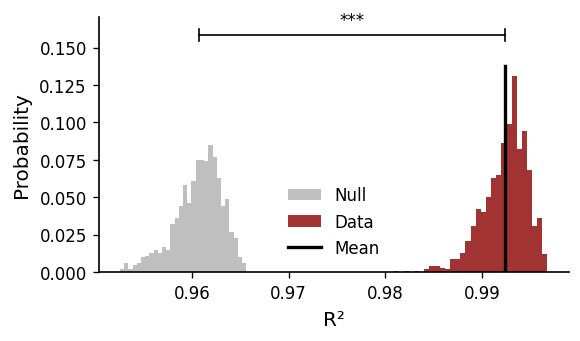

In [17]:
from scipy.stats import mannwhitneyu

def p_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'n.s.'

r_squared_vals = np.array([f['r_squared'] for f in torus_sweep])
r_squared_weights = np.ones_like(r_squared_vals) / len(r_squared_vals)

null_r2 = np.array([f['r_squared'] for f in null_sweep])
null_r2_weights = np.ones_like(null_r2) / len(null_r2)
_, p_r2 = mannwhitneyu(r_squared_vals, null_r2, alternative='two-sided')

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(null_r2, bins=30, weights=null_r2_weights, color='gray', alpha=0.5, label='Null')
ax.hist(r_squared_vals, bins=30, weights=r_squared_weights, color=color_alt, alpha=0.8, label='Data')
y_top = ax.get_ylim()[1]
ax.plot([r_squared_vals.mean(), r_squared_vals.mean()], [0, y_top], color='black', linewidth=2, label='Mean')

bar_y = y_top * 1.15
tick_h = y_top * 0.03
ax.plot([null_r2.mean(), null_r2.mean()], [bar_y - tick_h, bar_y + tick_h], color='black', linewidth=1, clip_on=False)
ax.plot([r_squared_vals.mean(), r_squared_vals.mean()], [bar_y - tick_h, bar_y + tick_h], color='black', linewidth=1, clip_on=False)
ax.plot([null_r2.mean(), r_squared_vals.mean()], [bar_y, bar_y], color='black', linewidth=1, clip_on=False)
ax.text((null_r2.mean() + r_squared_vals.mean()) / 2, bar_y + tick_h, p_to_stars(p_r2), ha='center', va='bottom', fontsize=10, clip_on=False)

prettify(ax, xlabel="R²", ylabel="Probability", add_legend=True)
plt.tight_layout()
plt.show()

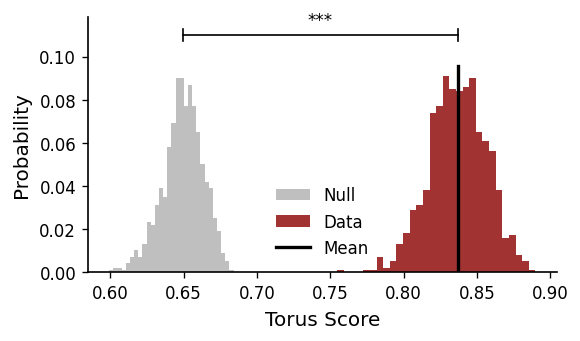

In [18]:
torus_score_vals = np.array([f['frac_inside'] for f in torus_sweep])
torus_score_weights = np.ones_like(torus_score_vals) / len(torus_score_vals)

null_ts = np.array([f['frac_inside'] for f in null_sweep])
null_ts_weights = np.ones_like(null_ts) / len(null_ts)
_, p_ts = mannwhitneyu(torus_score_vals, null_ts, alternative='two-sided')

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(null_ts, bins=30, weights=null_ts_weights, color='gray', alpha=0.5, label='Null')
ax.hist(torus_score_vals, bins=30, weights=torus_score_weights, color=color_alt, alpha=0.8, label='Data')
y_top = ax.get_ylim()[1]
ax.plot([torus_score_vals.mean(), torus_score_vals.mean()], [0, y_top], color='black', linewidth=2, label='Mean')

bar_y = y_top * 1.15
tick_h = y_top * 0.03
ax.plot([null_ts.mean(), null_ts.mean()], [bar_y - tick_h, bar_y + tick_h], color='black', linewidth=1, clip_on=False)
ax.plot([torus_score_vals.mean(), torus_score_vals.mean()], [bar_y - tick_h, bar_y + tick_h], color='black', linewidth=1, clip_on=False)
ax.plot([null_ts.mean(), torus_score_vals.mean()], [bar_y, bar_y], color='black', linewidth=1, clip_on=False)
ax.text((null_ts.mean() + torus_score_vals.mean()) / 2, bar_y + tick_h, p_to_stars(p_ts), ha='center', va='bottom', fontsize=10, clip_on=False)

prettify(ax, xlabel="Torus Score", ylabel="Probability", add_legend=True)
plt.tight_layout()
plt.show()

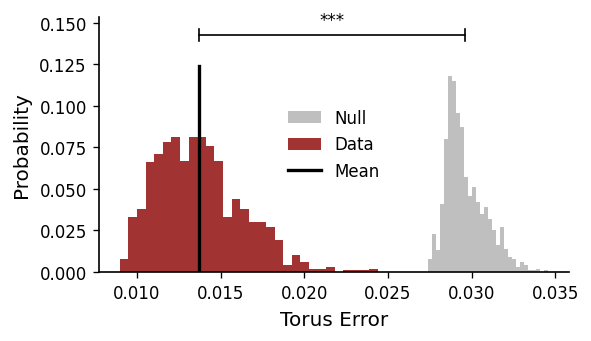

In [19]:
mean_error_vals = np.array([f['mean_error'] for f in torus_sweep])
mean_error_weights = np.ones_like(mean_error_vals) / len(mean_error_vals)

null_me = np.array([f['mean_error'] for f in null_sweep])
null_me_weights = np.ones_like(null_me) / len(null_me)
_, p_me = mannwhitneyu(mean_error_vals, null_me, alternative='two-sided')

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(null_me, bins=30, weights=null_me_weights, color='gray', alpha=0.5, label='Null')
ax.hist(mean_error_vals, bins=30, weights=mean_error_weights, color=color_alt, alpha=0.8, label='Data')
y_top = ax.get_ylim()[1]
ax.plot([mean_error_vals.mean(), mean_error_vals.mean()], [0, y_top], color='black', linewidth=2, label='Mean')

bar_y = y_top * 1.15
tick_h = y_top * 0.03
ax.plot([null_me.mean(), null_me.mean()], [bar_y - tick_h, bar_y + tick_h], color='black', linewidth=1, clip_on=False)
ax.plot([mean_error_vals.mean(), mean_error_vals.mean()], [bar_y - tick_h, bar_y + tick_h], color='black', linewidth=1, clip_on=False)
ax.plot([null_me.mean(), mean_error_vals.mean()], [bar_y, bar_y], color='black', linewidth=1, clip_on=False)
ax.text((null_me.mean() + mean_error_vals.mean()) / 2, bar_y + tick_h, p_to_stars(p_me), ha='center', va='bottom', fontsize=10, clip_on=False)

prettify(ax, xlabel="Torus Error", ylabel="Probability", add_legend=True)
plt.tight_layout()
plt.show()

## Taus

In [32]:
taus = np.arange(1, 101)
n_samples_per_tau = 10
max_start_tau = (len(xs_rescaled) / Fs) - window_size

# build all windows first
all_data_windows = []
all_null_windows = []
tau_indices = []

for tau in taus:
    starts = np.sort(np.random.uniform(0, max_start_tau, n_samples_per_tau))
    dw = make_windows(xs_rescaled, Fs=Fs, embedding_dim=3, tau=tau, starts_sec=starts.tolist(), window_sec=window_size)
    nw = make_windows(null_xs_rescaled, Fs=Fs, embedding_dim=3, tau=tau, starts_sec=starts.tolist(), window_sec=window_size)
    for w in dw:
        w['tau'] = tau
    for w in nw:
        w['tau'] = tau
    all_data_windows.extend(dw)
    all_null_windows.extend(nw)

# sweep all at once
all_data_fits = sweep_fits(all_data_windows, lam=0.1)
all_null_fits = sweep_fits(all_null_windows, lam=0.1)

# group back by tau
tau_results_data = {tau: [] for tau in taus}
tau_results_null = {tau: [] for tau in taus}
for f in all_data_fits:
    tau_results_data[f['tau']].append(f)
for f in all_null_fits:
    tau_results_null[f['tau']].append(f)

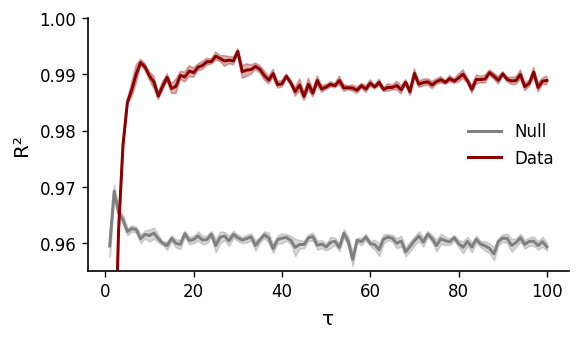

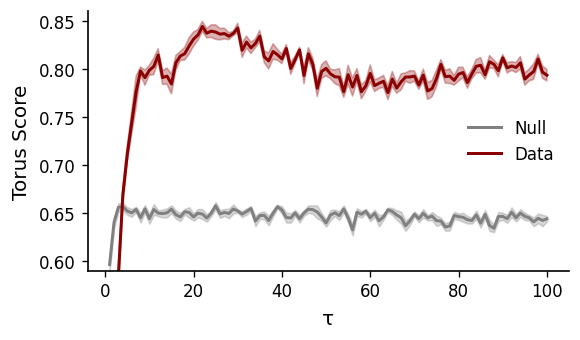

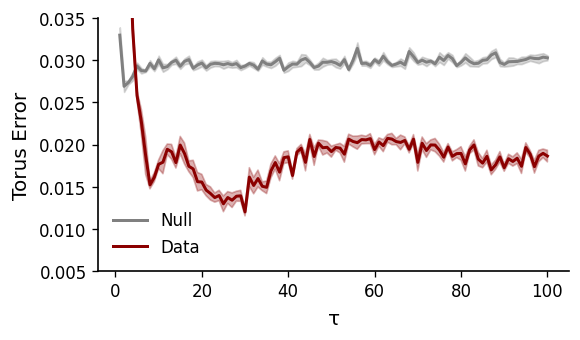

In [43]:
def extract_tau_stats(results_dict, key, taus):
    means = np.array([np.mean([f[key] for f in results_dict[tau]]) for tau in taus])
    sems = np.array([np.std([f[key] for f in results_dict[tau]]) / np.sqrt(len(results_dict[tau])) for tau in taus])
    return means, sems

for key, ylabel, ylim in [('r_squared', 'R²', (.955, 1)), ('frac_inside', 'Torus Score', (0.59, 0.86)), ('mean_error', 'Torus Error', (.005, .035))]:
    d_mean, d_sem = extract_tau_stats(tau_results_data, key, taus)
    n_mean, n_sem = extract_tau_stats(tau_results_null, key, taus)
    
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.fill_between(taus, n_mean - n_sem, n_mean + n_sem, color='gray', alpha=0.3)
    ax.plot(taus, n_mean, color='gray', label='Null')
    ax.fill_between(taus, d_mean - d_sem, d_mean + d_sem, color=color_alt, alpha=0.3)
    ax.plot(taus, d_mean, color=color_alt, label='Data')
    if ylim is not None:
        ax.set_ylim(ylim)
    prettify(ax, xlabel="τ", ylabel=ylabel, add_legend=True)
    plt.tight_layout()
    plt.show()

# Window size

In [45]:
min_samples_needed = (3 - 1) * optimal_tau + 1
min_window_sec = min_samples_needed / Fs
win_sizes = np.arange(np.ceil(min_window_sec * 10) / 10, 10.1, 0.1)
n_samples_per_win = 10

all_data_windows_win = []
all_null_windows_win = []

for ws in win_sizes:
    max_start_ws = (len(xs_rescaled) / Fs) - ws
    starts = np.sort(np.random.uniform(0, max_start_ws, n_samples_per_win))
    dw = make_windows(xs_rescaled, Fs=Fs, embedding_dim=3, tau=optimal_tau, starts_sec=starts.tolist(), window_sec=ws)
    nw = make_windows(null_xs_rescaled, Fs=Fs, embedding_dim=3, tau=optimal_tau, starts_sec=starts.tolist(), window_sec=ws)
    for w in dw:
        w['win_size'] = ws
    for w in nw:
        w['win_size'] = ws
    all_data_windows_win.extend(dw)
    all_null_windows_win.extend(nw)

all_data_fits_win = sweep_fits(all_data_windows_win)
all_null_fits_win = sweep_fits(all_null_windows_win)

win_results_data = {ws: [] for ws in win_sizes}
win_results_null = {ws: [] for ws in win_sizes}
for f in all_data_fits_win:
    win_results_data[f['win_size']].append(f)
for f in all_null_fits_win:
    win_results_null[f['win_size']].append(f)

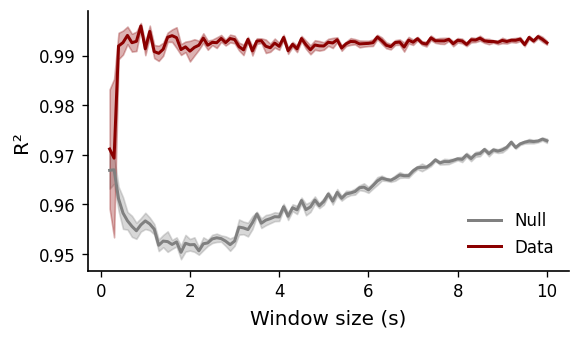

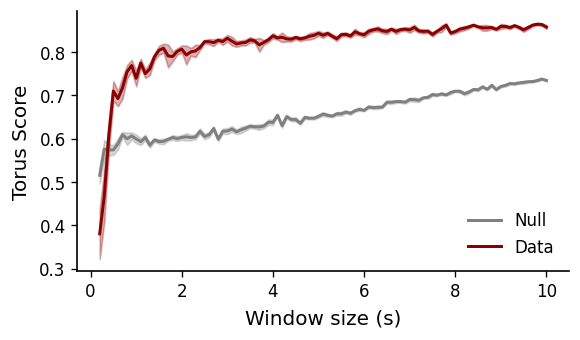

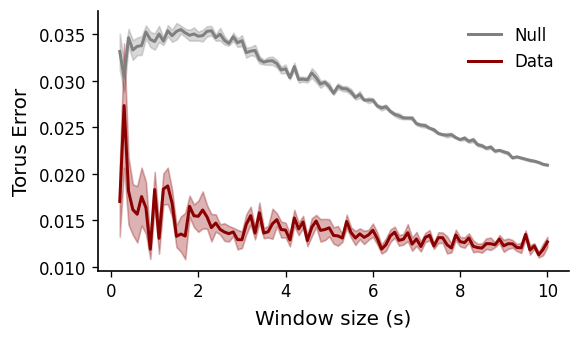

In [46]:
for key, ylabel, ylim in [('r_squared', 'R²', None), ('frac_inside', 'Torus Score', None), ('mean_error', 'Torus Error', None)]:
    d_mean, d_sem = extract_tau_stats(win_results_data, key, win_sizes)
    n_mean, n_sem = extract_tau_stats(win_results_null, key, win_sizes)
    
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.fill_between(win_sizes, n_mean - n_sem, n_mean + n_sem, color='gray', alpha=0.3)
    ax.plot(win_sizes, n_mean, color='gray', label='Null')
    ax.fill_between(win_sizes, d_mean - d_sem, d_mean + d_sem, color=color_alt, alpha=0.3)
    ax.plot(win_sizes, d_mean, color=color_alt, label='Data')
    if ylim is not None:
        ax.set_ylim(ylim)
    prettify(ax, xlabel="Window size (s)", ylabel=ylabel, add_legend=True)
    plt.tight_layout()
    plt.show()